# Fetal Health Prediction Model

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif


In [118]:
df = pd.read_csv(r'C:\Users\Bakwowi Junior\Documents\school-documents\4th-semester-SS-26\Machine Learning\ml-evaluation-project\datasets\fetal_health.csv')
df.head()



,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [14]:
# remove rows with missing values
# print("Number of rows before dropping missing values:", len(df))
# df = df.dropna()
# print("Number of rows after dropping missing values:", len(df))


In [48]:
# Check for missing values
# print(df.isnull().sum())

In [44]:
# Apply one-hot encoding to the target variable
# target_col = 'fetal_health'
# # Features (X) and raw target (y)
# X = df.drop(columns=[target_col])
# y = df[target_col].astype(int)
# # One-hot encode target for models that require one-hot labels
# ohe = OneHotEncoder(sparse_output=False)
# y_ohe = ohe.fit_transform(y.values.reshape(-1, 1))
# y_ohe = pd.DataFrame(y_ohe, columns=[f"{target_col}_{int(c)}" for c in ohe.categories_[0]])
# print('Target classes:', ohe.categories_)
# y_ohe.head()

In [43]:
# plot the distribution of the target variable
# plt.figure(figsize=(8, 6))
# plt.bar(y.value_counts().index, y.value_counts().values)
# plt.xlabel('Fetal Health Class')
# plt.ylabel('Count')
# plt.title('Distribution of Fetal Health Classes')
# plt.show()

In [42]:
# plot a scatter plot of the target variable against one of the features
# plt.figure(figsize=(8, 6))
# plt.scatter(X['accelerations'], y, alpha=0.5)
# plt.xlabel('Baseline Value')
# plt.ylabel('Fetal Health Class')
# plt.title('Baseline Value vs Fetal Health Class')
# plt.show()


In [119]:
print(len(df))
x = df.drop(columns=['fetal_health'])
y = df['fetal_health'].astype(int)
y = y.replace({1: 0, 2: 1, 3: 2})  # Map classes to 0, 1, 2 for better readability
y.value_counts()

2126


fetal_health
0    1655
1     295
2     176
Name: count, dtype: int64

In [138]:
# plot a correlation heatmap of the features with the target variable
# plt.figure(figsize=(12, 10))
# sns.heatmap(x.corrwith(y).to_frame(), annot=True, cmap='Blues')
# plt.title('Correlation Heatmap of Features with Target Variable')
# plt.show()

In [143]:
# plot a correlation heatmap of the features with each other
# plt.figure(figsize=(12, 10))
# sns.heatmap(x.corr(), annot=True, cmap='Blues')
# plt.title('Correlation Heatmap of Features with Each Other')
# plt.show()

In [ ]:
# draw a boxplot of the features with the target variable
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='fetal_health', y='baseline value')
plt.title('Boxplot of Baseline Value by Fetal Health Class')
plt.show()

In [120]:
# split data into train and test sets. Strify by target to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [121]:
print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

1700 426
1700 426


In [129]:
# Apply SMOTE to the training data to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Original training set class distribution:")
print(y_train.value_counts())
print("Resampled training set class distribution:")
print(y_train_resampled.value_counts())

Original training set class distribution:
fetal_health
0    1323
1     236
2     141
Name: count, dtype: int64
Resampled training set class distribution:
fetal_health
2    1323
0    1323
1    1323
Name: count, dtype: int64


In [147]:
selector = SelectKBest(
    score_func=f_classif,
    k=10
)
X_train_selected = selector.fit_transform(
    X_train_resampled, y_train_resampled
)

X_test_selected = selector.transform(X_test)
selected_features = X_train_resampled.columns[
    selector.get_support()
]

print(selected_features, len(selected_features))

Index(['baseline value', 'accelerations', 'prolongued_decelerations',
       'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'mean_value_of_long_term_variability', 'histogram_mode',
       'histogram_mean', 'histogram_median', 'histogram_variance'],
      dtype='str') 10


In [149]:
# create a pipeline for scaling, resampling, and modeling
# add feature selection step using SelectKBest with f_classif score function
# implement GridSearchCV to find the best hyperparameters for LogisticRegression


model = Pipeline([
    ('scaler', StandardScaler()),
    # ('smote', SMOTE(random_state=42)),
    # ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
    ('model', LinearDiscriminantAnalysis())
])


# Hyparameter grid for Logistic Regression
# param_grid = {

#     # Regularization strength
#     'model__C': [0.01, 0.1, 1, 10, 100],
#     'model__penalty': ['l1', 'l2', 'elasticnet'],

#     # Regularization type
#     'model__l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],  # Only used if penalty is 'elasticnet'

#     # Solver
#     'model__solver': ['saga']
# }

# Hyperparameter grid for Linear Discriminant Analysis
param_grid = [
    {
        'model__solver': ['svd']
    },
    {
        'model__solver': ['lsqr', 'eigen'],
        'model__shrinkage': [
            None,
            'auto',
            0.1,
            0.5,
            0.9
        ]
    }
]


grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    n_jobs=-1
)



In [40]:
# plot the stratified distribution of the target variable in the train and test sets
# fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# sns.countplot(x=y_train.columns[0], data=y_train, ax=axes[0])
# axes[0].set_title('Train Set Distribution')
# sns.countplot(x=y_test.columns[0], data=y_test, ax=axes[1])
# axes[1].set_title('Test Set Distribution')
# plt.show()

Fitting 5 folds for each of 11 candidates, totalling 55 fits
Best Parameters:
{'model__shrinkage': 'auto', 'model__solver': 'lsqr'}

Best Macro F1:
0.8680260388649357
                                               params  mean_test_score
0                            {'model__solver': 'svd'}         0.866306
1   {'model__shrinkage': None, 'model__solver': 'l...         0.866306
2   {'model__shrinkage': None, 'model__solver': 'e...              NaN
3   {'model__shrinkage': 'auto', 'model__solver': ...         0.868026
4   {'model__shrinkage': 'auto', 'model__solver': ...         0.868026
5   {'model__shrinkage': 0.1, 'model__solver': 'ls...         0.865248
6   {'model__shrinkage': 0.1, 'model__solver': 'ei...         0.865248
7   {'model__shrinkage': 0.5, 'model__solver': 'ls...         0.835298
8   {'model__shrinkage': 0.5, 'model__solver': 'ei...         0.835298
9   {'model__shrinkage': 0.9, 'model__solver': 'ls...         0.789801
10  {'model__shrinkage': 0.9, 'model__solver': 'ei..

c:\Users\Bakwowi Junior\miniconda3\envs\AI_VENV\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
4 fits failed out of a total of 55.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Bakwowi Junior\miniconda3\envs\AI_VENV\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Bakwowi Junior\miniconda3\envs\AI_VENV\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Bakwowi Junior\miniconda3\envs\AI_V

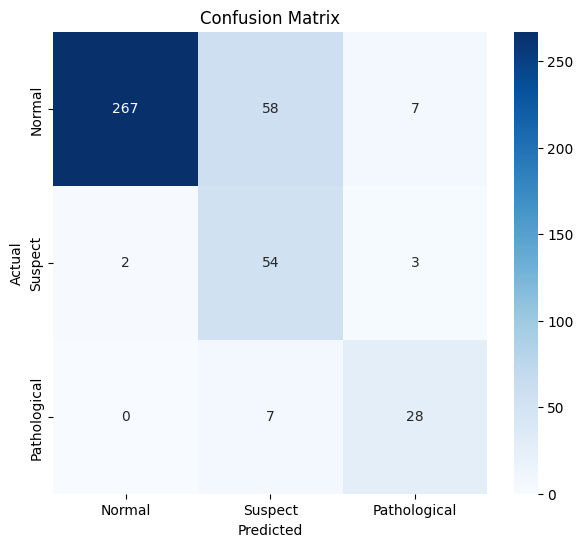

In [150]:
# ─────────────────────────────────────────────
# Train
# ─────────────────────────────────────────────
# grid_search.fit(X_train_resampled, y_train_resampled)

# fit the pipeline on the training data
y_pred = grid_search.fit(X_train_resampled, y_train_resampled).predict(X_test)


# ─────────────────────────────────────────────
# Best Results
# ─────────────────────────────────────────────
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Macro F1:")
print(grid_search.best_score_)


# print("Best Parameters:")
# print(grid_search.best_params_)

# print("\nBest CV Macro F1:")
# print(grid_search.best_score_)



# coef = model.coef_
# print('features ->', coef)



results = grid_search.cv_results_

df_results = pd.DataFrame(results)

print(df_results[
    ['params', 'mean_test_score']
])



# ──────────────────────────────────────────
# Basic Metrics
# ─────────────────────────────────────────────
accuracy = accuracy_score(y_test, y_pred)

precision_macro = precision_score(
    y_test, y_pred,
    average='macro'
)

recall_macro = recall_score(
    y_test, y_pred,
    average='macro'
)

f1_macro = f1_score(
    y_test, y_pred,
    average='macro'
)

f1_weighted = f1_score(
    y_test, y_pred,
    average='weighted'
)

# ─────────────────────────────────────────────
# Print Metrics
# ─────────────────────────────────────────────
print("Accuracy :", round(accuracy, 4))
print("Macro Precision :", round(precision_macro, 4))
print("Macro Recall :", round(recall_macro, 4))
print("Macro F1 :", round(f1_macro, 4))
print("Weighted F1 :", round(f1_weighted, 4))

# ─────────────────────────────────────────────
# Classification Report
# ─────────────────────────────────────────────
print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "Normal",
        "Suspect",
        "Pathological"
    ]
))

# ─────────────────────────────────────────────
# Confusion Matrix
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        "Normal",
        "Suspect",
        "Pathological"
    ],
    yticklabels=[
        "Normal",
        "Suspect",
        "Pathological"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

KeyError: 'key of type tuple not found and not a MultiIndex'